<a href="https://colab.research.google.com/github/gayurajeev/SCT_DA_3/blob/main/IBM_HR_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Analysis at IBM

## Business Problem

Employee attrition is one of the major challenges faced by organizations. High attrition leads to increased recruitment costs, training expenses, productivity loss, and reduced employee morale.

IBM's HR department wants to understand:

- Why employees are leaving
- Which employee groups are most likely to leave
- What factors contribute to attrition
- How attrition can be reduced

## Project Objective

The objective of this project is to analyze employee data and identify the key drivers of attrition. The findings will be presented through an interactive Tableau dashboard to support data-driven HR decisions.

## Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Tableau Public
- GitHub


In [23]:
import kagglehub
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [25]:

import os

print(os.listdir(path))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [26]:
import pandas as pd
import os

file_path = os.path.join(
    path,
    "WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

df = pd.read_csv(file_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [27]:
print(df.shape)
df.describe()

(1470, 35)


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [28]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


No missing values were found.


In [29]:
df['AttritionFlag'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})
df[['Attrition','AttritionFlag']].head()

,Attrition,AttritionFlag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0



For easier numerical analysis, the Attrition column is converted into a binary variable:

- Yes = 1
- No = 0 italicized text

In [30]:
total_employees = len(df)

print(total_employees)

1470


In [31]:
employees_left = len(df[df['Attrition']=='Yes'])

print(employees_left)

237


In [32]:
attrition_rate = (
    employees_left /
    total_employees
)*100

print(round(attrition_rate,2))

16.12


In [33]:
dept = df.groupby('Department')['AttritionFlag'].mean()*100

dept.sort_values(ascending=False)

,AttritionFlag
Department,
Sales,20.627803
Human Resources,19.047619
Research & Development,13.839750


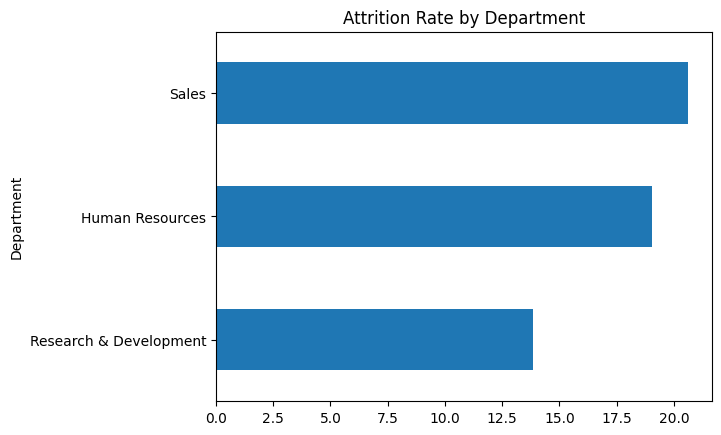

In [34]:
dept.sort_values().plot(
    kind='barh'
)

plt.title('Attrition Rate by Department')
plt.show()

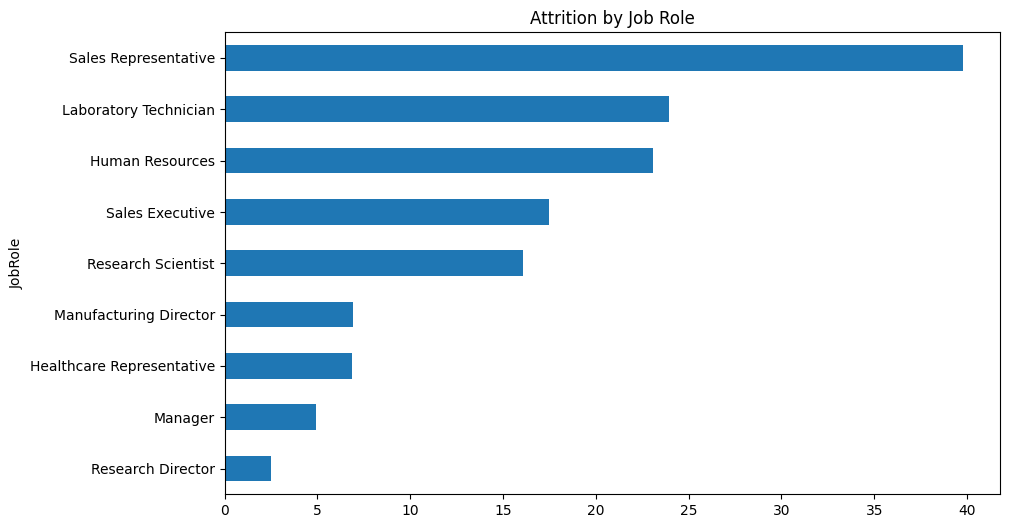

In [35]:
role = (
    df.groupby('JobRole')
    ['AttritionFlag']
    .mean()*100
)

role.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Attrition by Job Role')

plt.show()

In [36]:
overtime = (
    df.groupby('OverTime')
    ['AttritionFlag']
    .mean()*100
)

print(overtime)

OverTime
No     10.436433
Yes    30.528846
Name: AttritionFlag, dtype: float64


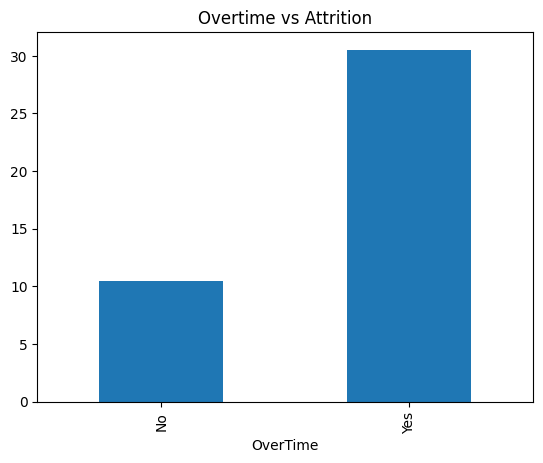

In [37]:
overtime.plot(
    kind='bar'
)

plt.title('Overtime vs Attrition')

plt.show()

Employees working overtime are significantly more likely to leave.


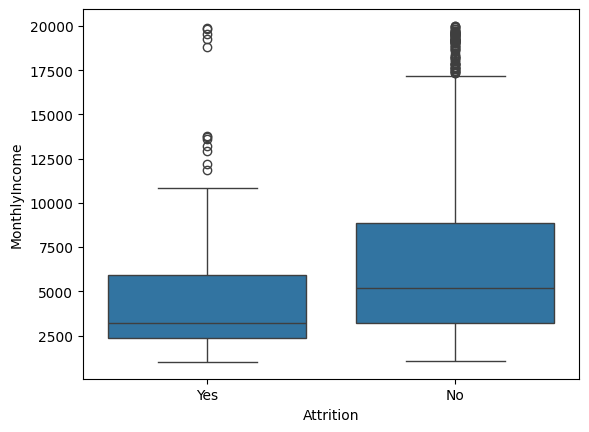

In [38]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.show()

Employees with lower salaries show higher attrition.

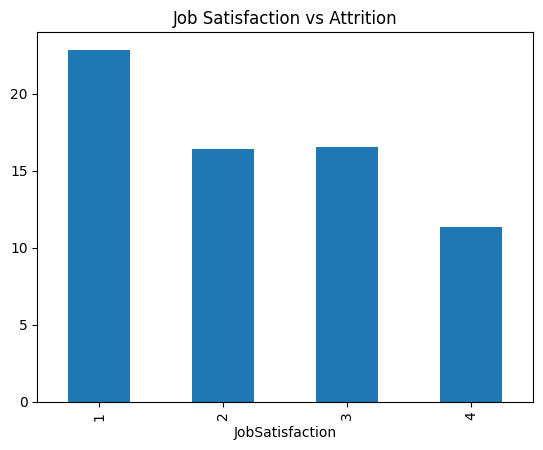

In [39]:
satisfaction = (
    df.groupby('JobSatisfaction')
    ['AttritionFlag']
    .mean()*100
)

satisfaction.plot(kind='bar')

plt.title('Job Satisfaction vs Attrition')

plt.show()


Lower job satisfaction levels are generally associated with higher attrition rates.

Improving employee engagement may help reduce turnover.

/tmp/ipykernel_3067/893708857.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')


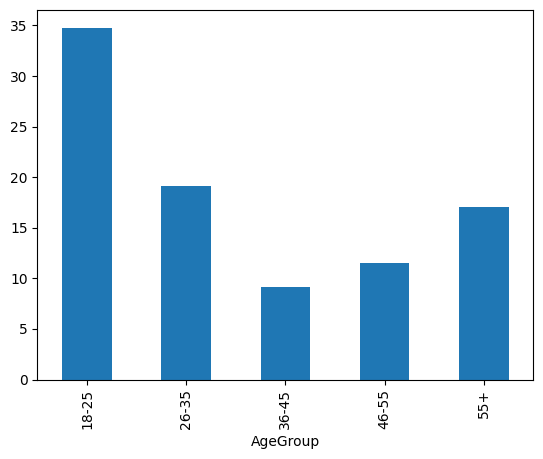

In [40]:
bins=[18,25,35,45,55,65]

labels=[
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '55+'
]

df['AgeGroup']=pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)
age = (
    df.groupby('AgeGroup')
    ['AttritionFlag']
    .mean()*100
)

age.plot(kind='bar')

plt.show()


Younger employees often display higher attrition rates due to career exploration and job mobility.


Based on the analysis, the following insights were identified:

1. Certain departments experience significantly higher attrition.
2. Employees working overtime are more likely to leave.
3. Lower job satisfaction is associated with increased attrition.
4. Younger employees show higher turnover rates.
5. Compensation may influence employee retention.

These findings will be incorporated into the Tableau dashboard.

In [41]:
df.to_csv(
    'IBM_HR_Cleaned.csv',
    index=False
)

In [42]:
from google.colab import files

files.download(
    'IBM_HR_Cleaned.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>